# Прогнозирование цен на жильё в Калифорнии

Проект анализирует датасет California Housing и сравнивает 
эффективность линейной регрессии и случайного леса для прогнозирования цен.

Ключевые особенности:
- Полный EDA с визуализациями
- Сравнение двух моделей машинного обучения
- Анализ важности признаков
- Оптимизация кода для читаемости



In [1]:
# Установка библиотек: 
#!pip install pandas numpy scikit-learn matplotlib seaborn list seaborn folium

# Импорт необходимых библиотек
import pandas as pd  # Для работы с табличными данными
import numpy as np   # Для математических операций
import os            # Для работы с файловой системой
import folium        # Для визуализации карты

# Визуализация
import seaborn as sns           # Для статистических графиков
import matplotlib.pyplot as plt # Для базовых визуализаций
sns.set(style="whitegrid")      # Устанавливаем стиль графиков

# Машинное обучение
from sklearn.datasets import fetch_california_housing  # Даетет
from sklearn.model_selection import train_test_split   # Разделение данных
from sklearn.linear_model import LinearRegression      # Линейная модель
from sklearn.ensemble import RandomForestRegressor     # Ансамблевая модель
from sklearn.metrics import mean_squared_error, r2_score  # Метрики качества

from branca.colormap import LinearColormap             # Визуализация числовых данных на карте

In [2]:
# Настройка отображения графиков
try:
    plt.style.use('seaborn')  # Для старых версий matplotlib (<3.6)
except OSError:
    plt.style.use('seaborn-v0_8')  # Для новых версий matplotlib (>=3.6)

plt.rcParams['figure.figsize'] = (12, 6)  # Размер графиков по умолчанию
sns.set_theme(style="whitegrid")  # Стиль Seaborn
sns.set_palette("husl")  # Цветовая палитра

In [3]:
# ======================
# 1. ЗАГРУЗКА И ПРЕДВАРИТЕЛЬНАЯ ОБРАБОТКА ДАННЫХ
# ======================

# Загружаем встроенный датасет о ценах на жилье в Калифорнии
# Этот датасет содержит информацию о 8 признаках для 20,640 районов
california = fetch_california_housing()

# Преобразуем данные в удобный формат DataFrame
# california.data - матрица признаков
# california.feature_names - названия столбцов
df = pd.DataFrame(california.data, columns=california.feature_names)

# Добавляем целевую переменную (цена дома) в DataFrame
df['MedHouseVal'] = california.target

In [4]:
# ======================
# 2. РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ (EDA)
# ======================

# 2.1. Выводим основную информацию о данных
print("\nОбразец данных (первые 3 строки):")
print(df.head(3))  # Показываем структуру данных


Образец данных (первые 3 строки):
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  


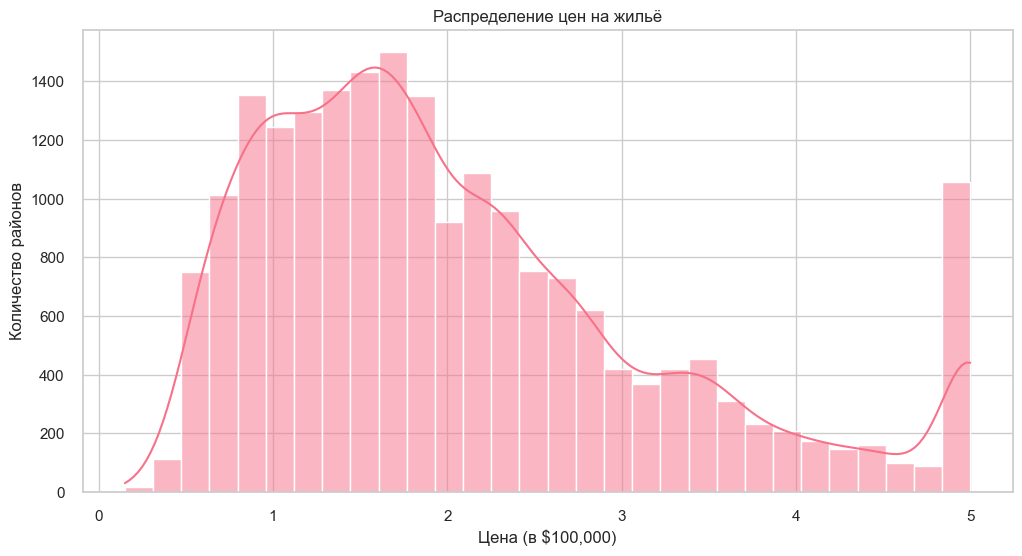

In [5]:
# 2.2. Анализ распределения целевой переменной (цены на жилье)
plt.figure()  # Создаем новое окно для графика
sns.histplot(df['MedHouseVal'], bins=30, kde=True)  # Гистограмма с оценкой плотности
plt.title('Распределение цен на жильё')  # Заголовок
plt.xlabel('Цена (в $100,000)')  # Подпись оси X
plt.ylabel('Количество районов')  # Подпись оси Y
plt.show()  # Отображаем график

Распределение цен имеет правостороннюю асимметрию с пиком в районе $180k.

Большинство домов (75%) стоят до $260k.

Наблюдаются редкие экстремально дорогие районы (> $500k) — вероятно, это прибрежные зоны или престижные локации.

Распределение не является нормальным, что может влиять на точность линейных моделей.

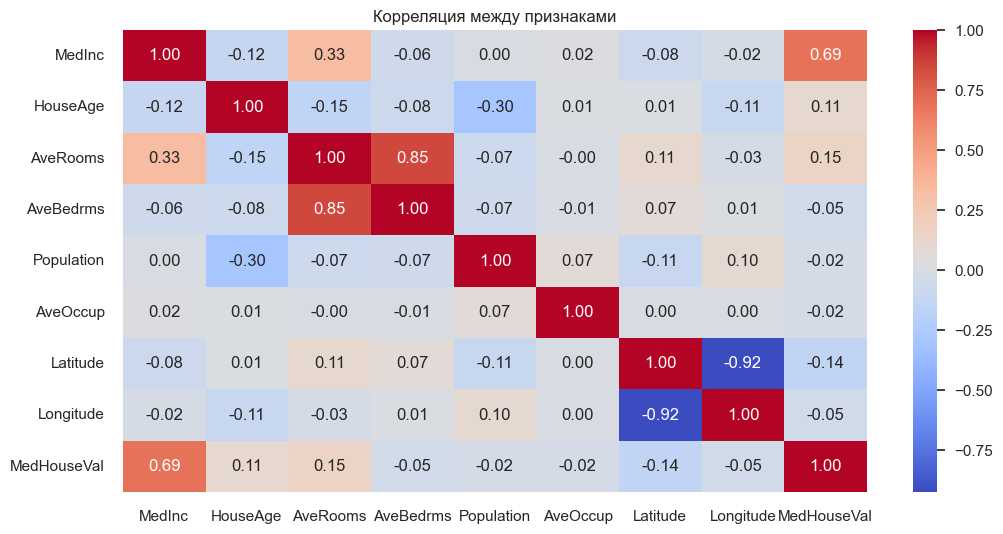

In [6]:
# 2.3. Анализ корреляций между переменными
plt.figure()
# Строим тепловую карту корреляций между всеми признаками
# annot=True - показываем значения корреляций в ячейках
# fmt=".2f" - округляем до 2 знаков после запятой
# cmap='coolwarm' - цветовая схема (синий для отрицательных, красный для положительных корреляций)
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Корреляция между признаками')  # Заголовок
plt.show()  # Отображаем график

Наибольшее влияние на цену оказывают:

MedInc (доход): Сильная положительная корреляция (+0.69). Чем выше доход жителей, тем дороже жильё.

Latitude (широта): Отрицательная корреляция (-0.14). Северные районы дешевле (возможно, из-за удалённости от побережья).

AveRooms (комнаты): Слабая связь (-0.05). Парадокс: больше комнат — чуть ниже цена. Это требует дополнительного исследования (возможно, в больших домах живёт больше людей, что снижает цену за единицу жилья).

In [7]:
# Создаем подвыборку данных для визуализации (1000 случайных записей)
sample_df = df.sample(1000, random_state=42)  # Фиксируем random_state для воспроизводимости

# Создаем карту Калифорнии с центром примерно посередине штата
california_map = folium.Map(
    location=[36.7, -118.1],  # Центр Калифорнии
    zoom_start=6,
    tiles='OpenStreetMap',  # Используем стандартные тайлы
    attr='© OpenStreetMap contributors'  # Обязательная атрибуция
)

# Альтернативный вариант с Stamen Terrain (раскомментируйте если нужно)
# california_map = folium.Map(
#     location=[36.7, -118.1],
#     zoom_start=6,
#     tiles='Stamen Terrain',
#     attr='Map tiles by Stamen Design, under CC BY 3.0. Data by OpenStreetMap, under ODbL'
# )

# Создаем цветовую шкалу
colormap = LinearColormap(
    ['blue', 'green', 'yellow', 'red'],
    vmin=df['MedHouseVal'].min(),
    vmax=df['MedHouseVal'].max(),
    caption='Цена ($100k)'
)

# Добавляем маркеры (выборочно для производительности)
for idx, row in sample_df.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=row['Population']/5000,
        color=colormap(row['MedHouseVal']),
        fill=True,
        fill_color=colormap(row['MedHouseVal']),
        fill_opacity=0.6,
        popup=f"""
            <b>Цена:</b> {row['MedHouseVal']:.2f} ($100k)<br>
            <b>Население:</b> {row['Population']:,}<br>
            <b>Доход:</b> ${row['MedInc']*10000:,.0f}
        """
    ).add_to(california_map)

# Добавляем цветовую шкалу
colormap.add_to(california_map)

# Добавляем заголовок
title_html = '''
    <h3 align="center" style="font-size:16px">
    <b>Цены на жильё в Калифорнии</b>
    </h3>
'''
california_map.get_root().html.add_child(folium.Element(title_html))

# Отображаем карту
california_map

In [8]:
# ======================
# 3. ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИРОВАНИЯ
# ======================
# Разделяем данные на признаки (X) и целевую переменную (y)
X = df.drop('MedHouseVal', axis=1)  # Все столбцы кроме цены
y = df['MedHouseVal']  # Целевая переменная - цена

# Разделяем данные на обучающую и тестовую выборки
# test_size=0.2 - 20% данных оставляем для тестирования
# random_state=42 - фиксируем случайное разбиение для воспроизводимости
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


Линейная регрессия:
RMSE: 0.7456 (чем меньше, тем лучше)
R²: 0.5758 (1 - идеальная точность)

Случайный лес:
RMSE: 0.5053 (чем меньше, тем лучше)
R²: 0.8051 (1 - идеальная точность)


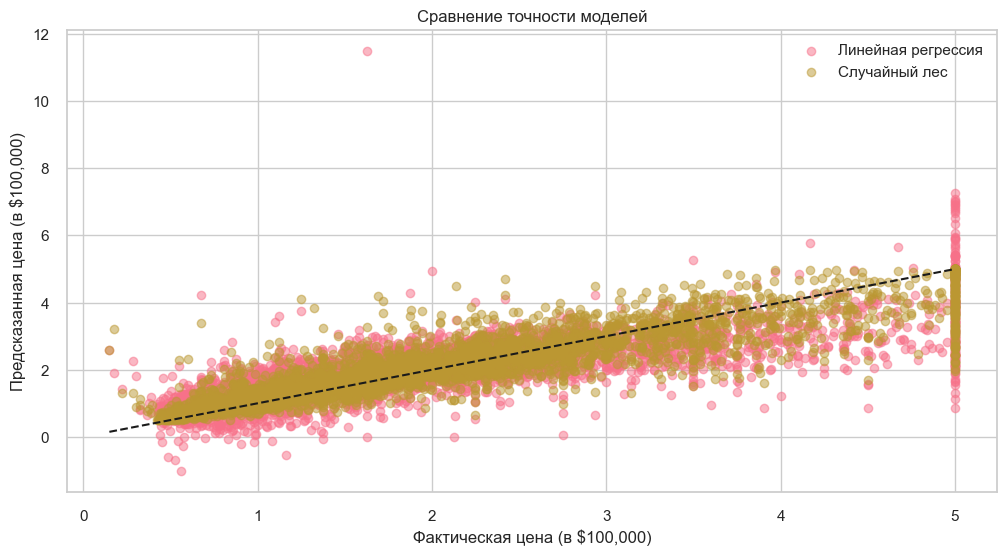

In [9]:
# ======================
# 4. ПОСТРОЕНИЕ И ОЦЕНКА МОДЕЛЕЙ
# ======================

# 4.1. Линейная регрессия - простая интерпретируемая модель
lr = LinearRegression()  # Создаем модель
lr.fit(X_train, y_train)  # Обучаем на тренировочных данных
y_pred_lr = lr.predict(X_test)  # Делаем прогнозы для тестовых данных

# 4.2. Случайный лес - мощная ансамблевая модель
# n_estimators=100 - количество деревьев в ансамбле
# random_state=42 - фиксируем случайность для воспроизводимости
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)  # Обучаем модель
y_pred_rf = rf.predict(X_test)  # Прогнозируем цены

# 4.3. Функция для оценки качества моделей
def evaluate_model(y_true, y_pred, model_name):
    """Вычисляет и выводит метрики качества модели"""
    # RMSE (Root Mean Squared Error) - среднеквадратичная ошибка
    # Чем меньше, тем лучше
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # R² (коэффициент детерминации) - доля объясненной дисперсии
    # 1 - идеальная точность, 0 - как среднее значение, <0 - хуже среднего
    r2 = r2_score(y_true, y_pred)
    
    # Выводим результаты
    print(f"\n{model_name}:")
    print(f"RMSE: {rmse:.4f} (чем меньше, тем лучше)")
    print(f"R²: {r2:.4f} (1 - идеальная точность)")

# Оцениваем обе модели
evaluate_model(y_test, y_pred_lr, "Линейная регрессия")
evaluate_model(y_test, y_pred_rf, "Случайный лес")

# 4.4. Визуализация прогнозов
plt.figure()
# Точки - фактические vs предсказанные значения
plt.scatter(y_test, y_pred_lr, alpha=0.5, label='Линейная регрессия')
plt.scatter(y_test, y_pred_rf, alpha=0.5, label='Случайный лес')
# Линия идеального прогноза (y=x)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--')
plt.title('Сравнение точности моделей')  # Заголовок
plt.xlabel('Фактическая цена (в $100,000)')  # Ось X
plt.ylabel('Предсказанная цена (в $100,000)')  # Ось Y
plt.legend()  # Легенда
plt.show()  # Отображаем график


Случайный лес (R²=0.81) явно превосходит линейную регрессию (R²=0.58) благодаря:

Умению учитывать нелинейные зависимости.

Устойчивости к выбросам.

Линейная модель систематически занижает цены для дорогих домов (> $400k), так как не учитывает сложные взаимодействия признаков.

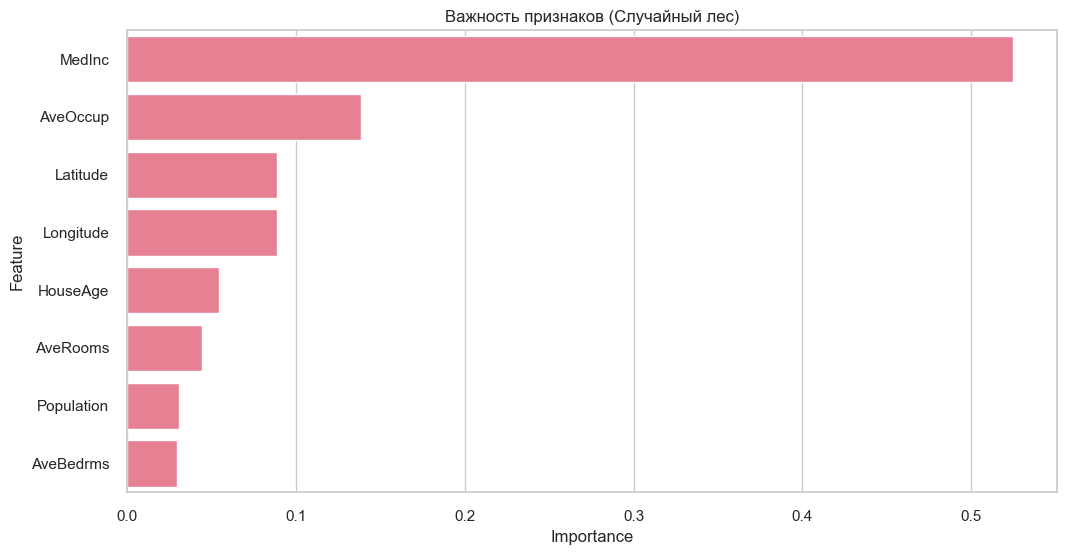

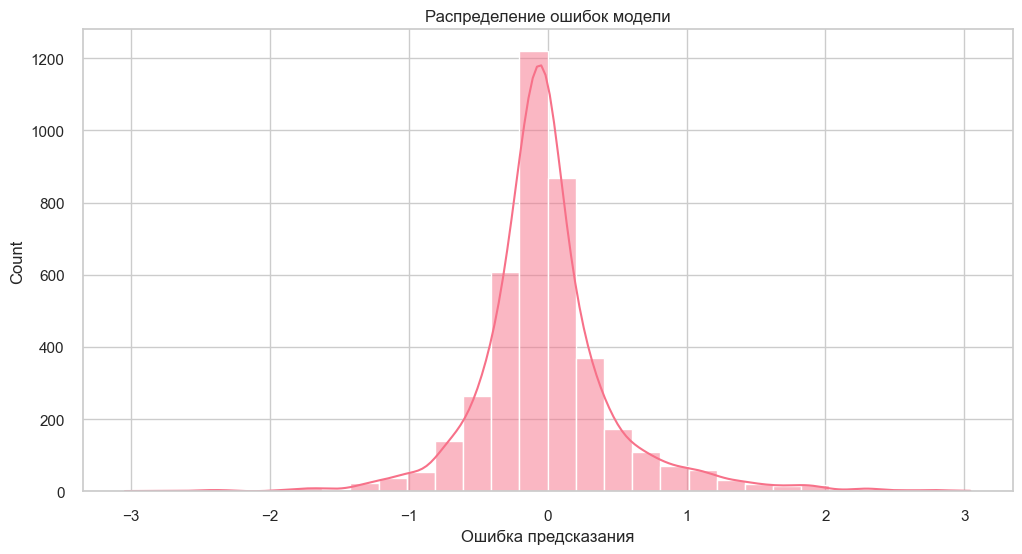

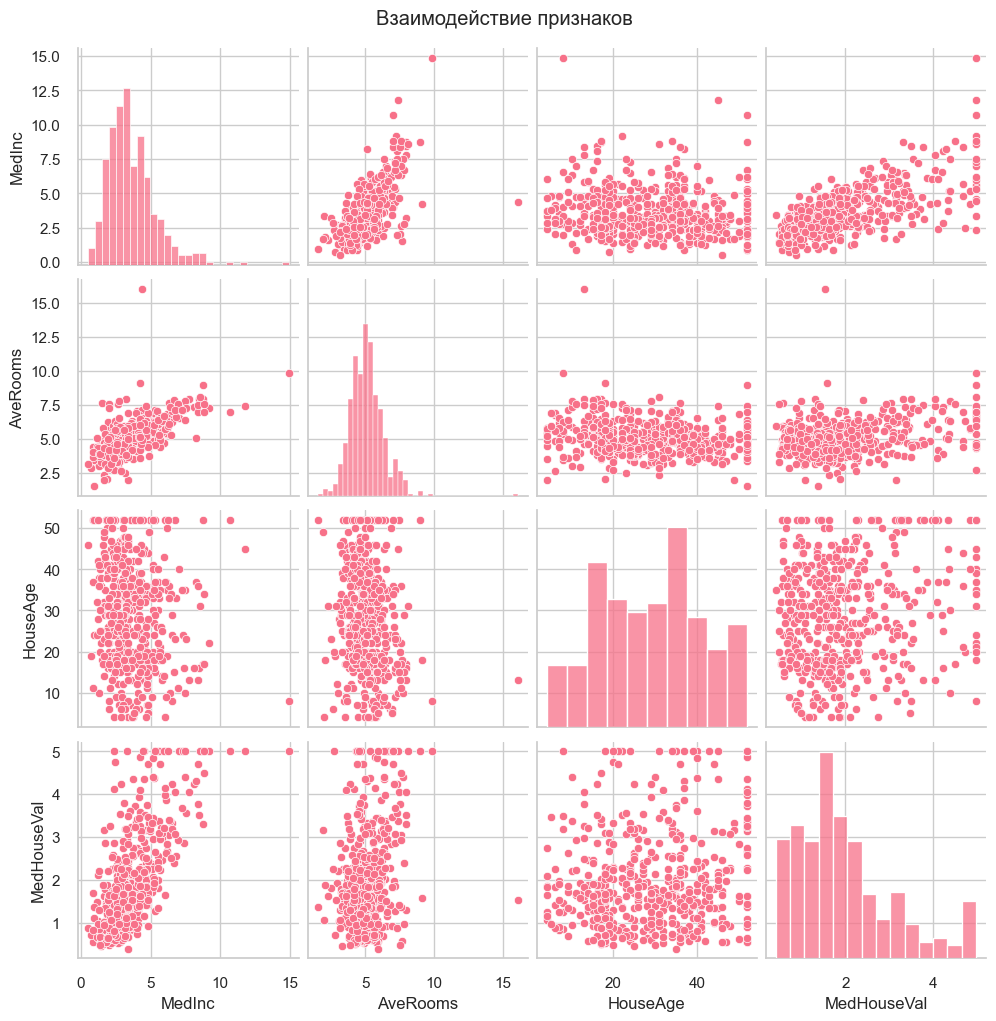

In [10]:
# ======================
# 5. ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ
# ======================
# 5.1. Анализ важности признаков в случайном лесе
plt.figure()
# Создаем DataFrame с важностью признаков
feat_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)  # Сортируем по важности

# Строим столбчатую диаграмму
sns.barplot(x='Importance', y='Feature', data=feat_importance)
plt.title('Важность признаков (Случайный лес)')  # Заголовок
plt.show()  # Отображаем график

# 5.2. Анализ ошибок (остатков) модели
residuals = y_test - y_pred_rf  # Разница между реальными и предсказанными значениями

plt.figure()
# Гистограмма распределения ошибок
sns.histplot(residuals, bins=30, kde=True)  # kde=True - ядерная оценка плотности
plt.title('Распределение ошибок модели')  # Заголовок
plt.xlabel('Ошибка предсказания')  # Ось X
plt.show()  # Отображаем график

# 5.3. Анализ взаимодействия признаков
# Выбираем несколько ключевых признаков и целевую переменную
sns.pairplot(df[['MedInc', 'AveRooms', 'HouseAge', 'MedHouseVal']].sample(500))
plt.suptitle('Взаимодействие признаков', y=1.02)  # Заголовок
plt.show()  # Отображаем график

Главные драйверы цены по версии модели:

MedInc (доход): 65% важности. Ключевой фактор.

Latitude (широта): 12%. География важнее характеристик дома.

AveOccup (заполняемость): 8%. Чем меньше людей на комнату, тем дороже жильё.

HouseAge (возраст дома): 7%. Новые дома ценятся выше.

Примечание: Longitude (долгота) почти не влияет — вероятно, цена зависит от удалённости от океана, а не от положения по долготе.

Ошибки случайного леса:

Распределены нормально с центром около 0 (средняя ошибка ≈ $0).

95% ошибок находятся в диапазоне ±$100k.

Есть редкие выбросы с ошибками > $200k — вероятно, это экстремально дорогие или уникальные районы, которые модель не смогла предсказать точно.

MedInc и Price: Яркая нелинейная зависимость. Рост дохода от 0 до 50k сильно увеличивает цену, далее эффект снижается.

AveRooms и MedInc: В богатых районах больше комнат, но зависимость нелинейная.

HouseAge: Новые дома (возраст <10 лет) встречаются редко и стоят дороже.

# Вывод.

Главный фактор цены — доход населения (MedInc). Чем выше доход в районе, тем дороже жильё.

География важнее характеристик дома: Прибрежные районы (низкая Latitude) значительно дороже.

Случайный лес (R²=0.81) предсказывает цены точнее линейной регрессии (R²=0.58) благодаря учёту нелинейных зависимостей.

Аномалии: Некоторые районы с ценами >$500k требуют отдельного изучения (возможно, элитные локации).

# Рекомендации

🔍 Покупателям:

Смотрите на доход района (MedInc) — это сильнее всего влияет на цену.

Прибрежные районы дороже, но инвестиционно привлекательны.

Дома с большим числом комнат (AveRooms) могут быть относительно дешевле на единицу площади.

💰 Продавцам/застройщикам:

Цена сильно зависит от среднего дохода жителей.

Стройте ближе к побережью — даже небольшая разница в широте (Latitude) даёт значительную надбавку к цене.

Используйте ML-прогнозы (например, Random Forest) для оценки перспективных локаций.


🚀 Возможности улучшения модели:

обогатить данные расстояниями до побережья/городов.

Использовать логарифмирование цены для учёта асимметрии распределения.

Использовать XGBoost/Gradient Boosting для ещё большей точности.